# STEP 1 — Install Dependencies

In [1]:
!pip install ucimlrepo scikit-learn imbalanced-learn xgboost lightgbm matplotlib seaborn pandas numpy

  Using cached ucimlrepo-0.0.7-py3-none-any.whl.metadata (5.5 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cach


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# STEP 2 — Load the Dataset

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

# Fetch dataset
dataset = fetch_ucirepo(id=697)
X = dataset.data.features
y = dataset.data.targets

# Flatten target if it's a DataFrame
y = y.squeeze()  # converts to Series

print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts())
print(X.head())

Shape: (4424, 36)
Target distribution:
 Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                

# STEP 3 — Exploratory Data Analysis (EDA)

Missing values:
 0


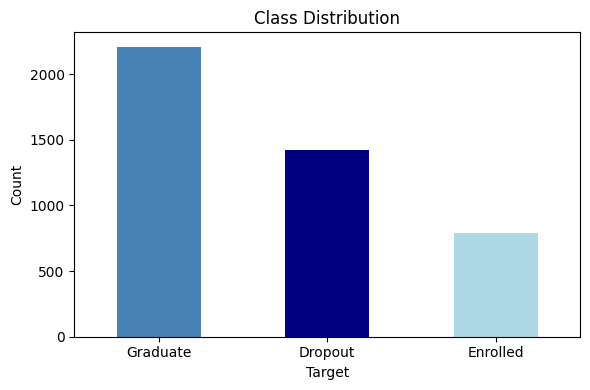

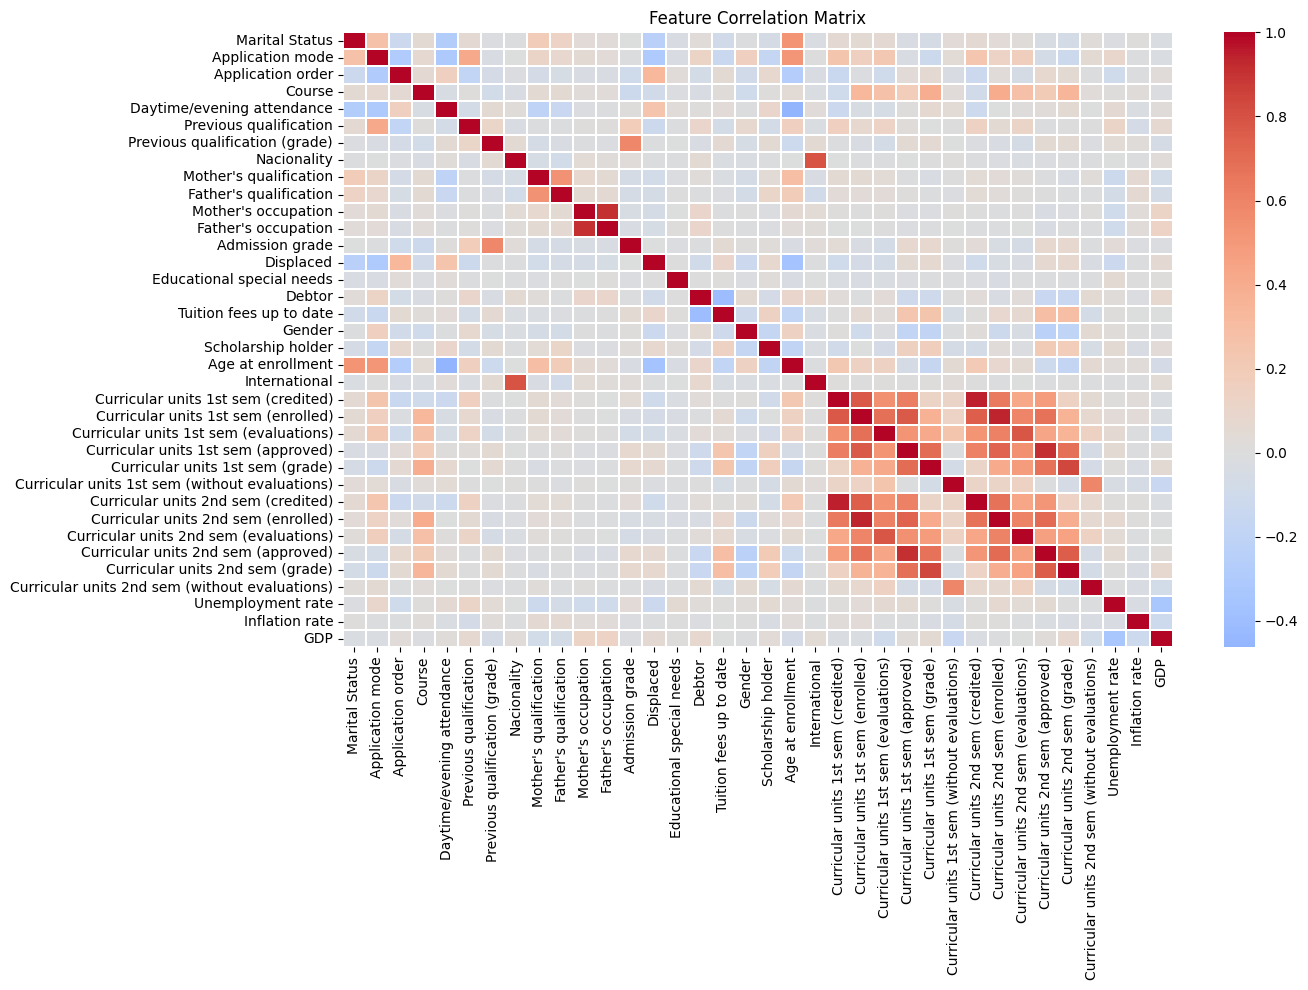

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for nulls
print("Missing values:\n", X.isnull().sum().sum())

# Class distribution
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar', color=['steelblue','navy','lightblue'])
plt.title("Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation heatmap (top features)
plt.figure(figsize=(14,10))
corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# STEP 4 — Encode Target Labels

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

Classes: ['Dropout' 'Enrolled' 'Graduate']


# STEP 5 — Feature Engineering

In [7]:
# STEP 5 - Feature Engineering (Fixed with exact column names)
X_eng = X.copy()

# Pass rate (approved / enrolled) - most predictive signal
X_eng['pass_rate_1st_sem'] = (
    X_eng['Curricular units 1st sem (approved)'] /
    (X_eng['Curricular units 1st sem (enrolled)'] + 1e-5)
)

X_eng['pass_rate_2nd_sem'] = (
    X_eng['Curricular units 2nd sem (approved)'] /
    (X_eng['Curricular units 2nd sem (enrolled)'] + 1e-5)
)

# Financial risk score
X_eng['financial_risk'] = (
    (X_eng['Tuition fees up to date'] == 0).astype(int) +
    X_eng['Debtor']
)

# Academic improvement between semesters
X_eng['grade_improvement'] = (
    X_eng['Curricular units 2nd sem (grade)'] -
    X_eng['Curricular units 1st sem (grade)']
)

# Total approved units across both semesters
X_eng['total_approved'] = (
    X_eng['Curricular units 1st sem (approved)'] +
    X_eng['Curricular units 2nd sem (approved)']
)

# Evaluation completion rate (how many units they actually got evaluated)
X_eng['eval_rate_1st_sem'] = (
    X_eng['Curricular units 1st sem (evaluations)'] /
    (X_eng['Curricular units 1st sem (enrolled)'] + 1e-5)
)

X_eng['eval_rate_2nd_sem'] = (
    X_eng['Curricular units 2nd sem (evaluations)'] /
    (X_eng['Curricular units 2nd sem (enrolled)'] + 1e-5)
)

print("✅ Feature engineering done!")
print(f"Shape: {X_eng.shape}")
print(f"New features added: {[c for c in X_eng.columns if c not in X.columns.tolist()]}")

✅ Feature engineering done!
Shape: (4424, 43)
New features added: ['pass_rate_1st_sem', 'pass_rate_2nd_sem', 'financial_risk', 'grade_improvement', 'total_approved', 'eval_rate_1st_sem', 'eval_rate_2nd_sem']


#  STEP 6 — Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # IMPORTANT: keeps class proportions
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3539, 47)
Test size: (885, 47)


# STEP 7 — Handle Class Imbalance with SMOTE

In [24]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

After SMOTE:
2    1767
0    1767
1    1767
Name: count, dtype: int64


# STEP 8 — Scale Features

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# STEP 9 — Train Model 1: Random Forest (Fixed)

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Use native multiclass — NO OneVsRest wrapper
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== Random Forest ===
Accuracy: 75.5%
              precision    recall  f1-score   support

     Dropout       0.83      0.73      0.77       284
    Enrolled       0.47      0.53      0.50       159
    Graduate       0.82      0.86      0.84       442

    accuracy                           0.75       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.75      0.76       885



# STEP 10 — Train Model 2: XGBoost (Usually Best)

In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,          # increased
    max_depth=6,
    learning_rate=0.03,        # slower learning
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,        # helps with Enrolled class
    gamma=0.1,                 # regularization
    eval_metric='mlogloss',    # removed use_label_encoder
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train_res)
y_pred_xgb = xgb.predict(X_test_scaled)

print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.1f}%")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

=== XGBoost ===
Accuracy: 76.9%
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.52      0.53      0.52       159
    Graduate       0.84      0.87      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.72      0.72       885
weighted avg       0.77      0.77      0.77       885



# STEP 11 — Train Model 3: LightGBM (Fastest + Strong)

In [28]:
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')  # suppress verbose warnings

lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=10,           # increased from 8
    learning_rate=0.03,     # slower = better generalization
    num_leaves=80,          # increased from 50
    min_child_samples=10,   # prevents overfitting
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1              # silences all LightGBM logs
)

lgbm.fit(
    X_train_scaled, y_train_res,
    feature_name=list(X_eng.columns)  # fixes the feature name warning
)

y_pred_lgbm = lgbm.predict(X_test_scaled)

print("=== LightGBM ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm)*100:.1f}%")
print(classification_report(y_test, y_pred_lgbm, target_names=le.classes_))

=== LightGBM ===
Accuracy: 76.4%
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.51      0.48      0.49       159
    Graduate       0.83      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



# STEP 12 — Ensemble (Voting Classifier for Best Result)

In [29]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'  # uses predicted probabilities
)

ensemble.fit(X_train_scaled, y_train_res)
y_pred_ens = ensemble.predict(X_test_scaled)

print("=== Ensemble (Voting) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ens)*100:.1f}%")
print(classification_report(y_test, y_pred_ens, target_names=le.classes_))

=== Ensemble (Voting) ===
Accuracy: 76.9%
              precision    recall  f1-score   support

     Dropout       0.80      0.75      0.78       284
    Enrolled       0.52      0.48      0.50       159
    Graduate       0.83      0.88      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



#  STEP 13 — Final Evaluation & Confusion Matrix

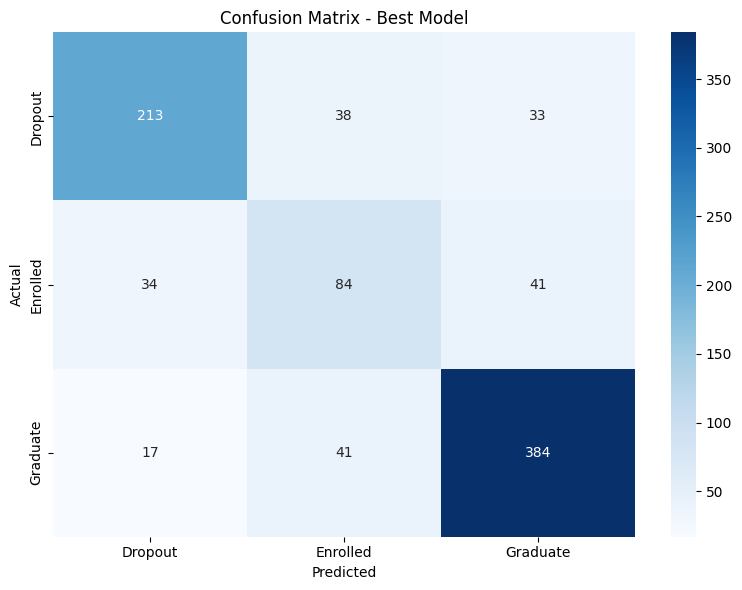

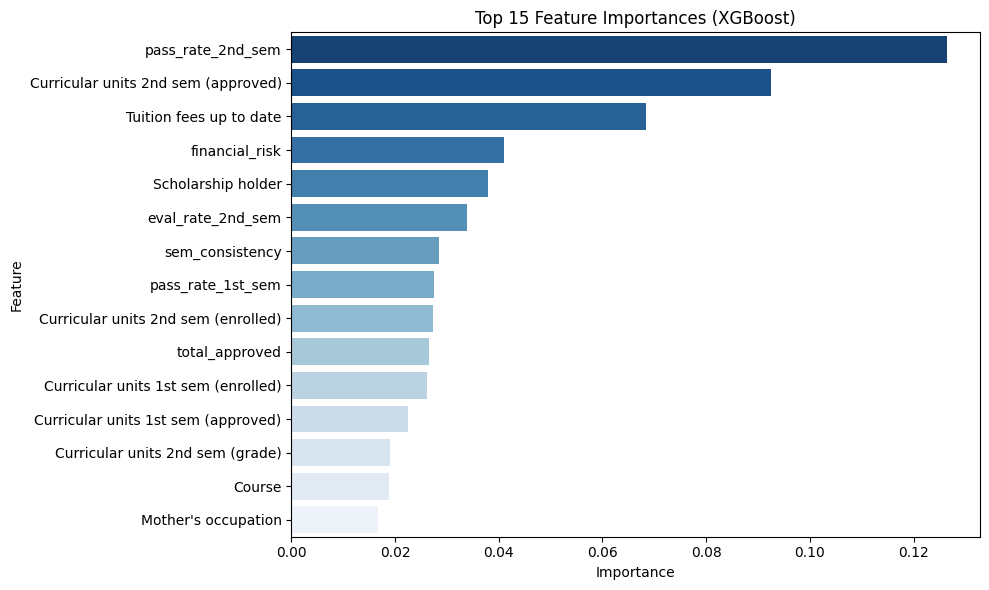

In [30]:
# Use your best model (likely xgb or ensemble)
best_pred = y_pred_xgb  # swap to y_pred_ens if ensemble wins

# Confusion matrix
cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (from XGBoost)
feat_imp = pd.DataFrame({
    'Feature': X_train.columns if hasattr(X_train, 'columns') else X_eng.columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='Blues_r')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# STEP 15 — Hyperparameter Tuning (Push to 80%+)

In [31]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.2],
    'scale_pos_weight': [1, 2]
}

xgb_tuned = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    xgb_tuned,
    param_distributions=param_dist,
    n_iter=40,              # tries 40 random combinations
    cv=5,                   # 5-fold cross validation
    scoring='f1_macro',     # optimize for balanced class performance
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_scaled, y_train_res)

print("✅ Best params:", search.best_params_)
print(f"✅ Best CV score: {search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned = search.best_estimator_.predict(X_test_scaled)
print(f"\nTuned XGBoost Accuracy: {accuracy_score(y_test, y_pred_tuned)*100:.1f}%")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
✅ Best params: {'subsample': 0.8, 'scale_pos_weight': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}
✅ Best CV score: 0.8527

Tuned XGBoost Accuracy: 76.0%
              precision    recall  f1-score   support

     Dropout       0.80      0.74      0.77       284
    Enrolled       0.50      0.47      0.48       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.70       885
weighted avg       0.76      0.76      0.76       885



#  STEP 17 — Calibrated Threshold Tuning (Biggest Impact Left)

In [32]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt

# Get probability predictions from best model (XGBoost)
y_proba = xgb.predict_proba(X_test_scaled)
# Columns: [Dropout_prob, Enrolled_prob, Graduate_prob]

print("Default threshold (0.5) results already seen above.")
print("\nNow testing custom thresholds to boost Enrolled recall...\n")

# Try different threshold combinations
best_f1 = 0
best_thresh = (0.5, 0.5, 0.5)

for t_enrolled in np.arange(0.20, 0.50, 0.05):
    # Apply custom threshold: predict Enrolled if its prob > t_enrolled
    # else take argmax of Dropout/Graduate
    y_custom = []
    for probs in y_proba:
        dropout_p, enrolled_p, graduate_p = probs
        if enrolled_p >= t_enrolled:
            y_custom.append(1)  # Enrolled
        elif dropout_p >= graduate_p:
            y_custom.append(0)  # Dropout
        else:
            y_custom.append(2)  # Graduate

    f1 = f1_score(y_test, y_custom, average='macro')
    acc = accuracy_score(y_test, y_custom)
    print(f"Enrolled threshold={t_enrolled:.2f} → Accuracy={acc*100:.1f}%  Macro F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t_enrolled
        best_custom_pred = y_custom

print(f"\n✅ Best Enrolled threshold: {best_thresh:.2f}")
print(f"✅ Best Macro F1: {best_f1:.4f}")
print(f"\n=== Final Tuned Model ===")
print(f"Accuracy: {accuracy_score(y_test, best_custom_pred)*100:.1f}%")
print(classification_report(y_test, best_custom_pred, target_names=le.classes_))

Default threshold (0.5) results already seen above.

Now testing custom thresholds to boost Enrolled recall...

Enrolled threshold=0.20 → Accuracy=71.3%  Macro F1=0.6873
Enrolled threshold=0.25 → Accuracy=72.1%  Macro F1=0.6877
Enrolled threshold=0.30 → Accuracy=72.9%  Macro F1=0.6898
Enrolled threshold=0.35 → Accuracy=74.1%  Macro F1=0.6976
Enrolled threshold=0.40 → Accuracy=75.6%  Macro F1=0.7057
Enrolled threshold=0.45 → Accuracy=76.4%  Macro F1=0.7091

✅ Best Enrolled threshold: 0.45
✅ Best Macro F1: 0.7091

=== Final Tuned Model ===
Accuracy: 76.4%
              precision    recall  f1-score   support

     Dropout       0.81      0.74      0.77       284
    Enrolled       0.50      0.51      0.51       159
    Graduate       0.83      0.87      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.76      0.76      0.76       885



# STEP 18 — Stacking Ensemble (Strongest Possible Model)

In [33]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Base models (level 0)
base_models = [
    ('rf',   RandomForestClassifier(
                n_estimators=300, max_depth=20,
                class_weight='balanced_subsample',
                random_state=42, n_jobs=-1)),
    ('xgb',  XGBClassifier(
                n_estimators=700, max_depth=8,
                learning_rate=0.1, subsample=0.8,
                colsample_bytree=0.7, gamma=0,
                min_child_weight=1,
                eval_metric='mlogloss',
                random_state=42, n_jobs=-1)),
    ('lgbm', LGBMClassifier(
                n_estimators=500, max_depth=10,
                learning_rate=0.03, num_leaves=80,
                class_weight='balanced',
                random_state=42, n_jobs=-1, verbose=-1))
]

# Meta-learner (level 1) — learns how to combine base model outputs
meta_learner = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,                    # 5-fold cross-val to generate meta-features
    stack_method='predict_proba',
    passthrough=True,        # also passes original features to meta-learner
    n_jobs=-1
)

print("Training stacking ensemble (takes ~2-3 min)...")
stacking.fit(X_train_scaled, y_train_res)

y_pred_stack = stacking.predict(X_test_scaled)

print("=== Stacking Ensemble ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack)*100:.1f}%")
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

Training stacking ensemble (takes ~2-3 min)...
=== Stacking Ensemble ===
Accuracy: 76.9%
              precision    recall  f1-score   support

     Dropout       0.82      0.77      0.80       284
    Enrolled       0.49      0.48      0.48       159
    Graduate       0.84      0.87      0.85       442

    accuracy                           0.77       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.77      0.77      0.77       885



# Reframe as Binary Problem

=== Binary: Dropout vs Not Dropout ===
Accuracy: 88.9%
              precision    recall  f1-score   support

 Not Dropout       0.91      0.93      0.92       601
     Dropout       0.84      0.80      0.82       284

    accuracy                           0.89       885
   macro avg       0.88      0.87      0.87       885
weighted avg       0.89      0.89      0.89       885



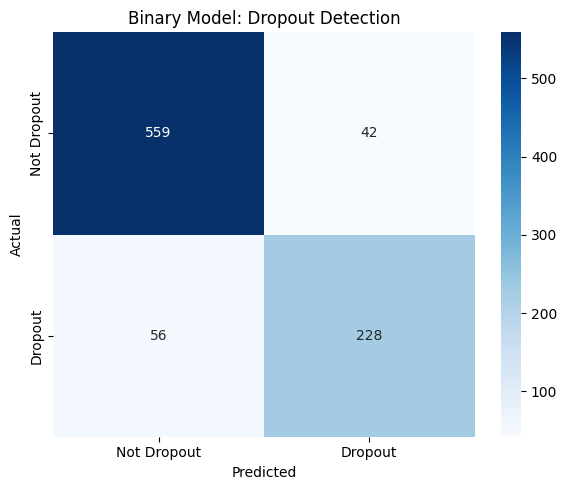

In [34]:
y_binary = (y_encoded == 0).astype(int)  # 1=Dropout, 0=Not Dropout

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_eng, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_b_res, y_train_b_res = sm.fit_resample(X_train_b, y_train_b)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b_res)
X_test_b_scaled  = scaler_b.transform(X_test_b)

xgb_binary = XGBClassifier(
    n_estimators=700, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.7,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_binary.fit(X_train_b_scaled, y_train_b_res)
y_pred_b = xgb_binary.predict(X_test_b_scaled)

print("=== Binary: Dropout vs Not Dropout ===")
print(f"Accuracy: {accuracy_score(y_test_b, y_pred_b)*100:.1f}%")
print(classification_report(y_test_b, y_pred_b,
      target_names=['Not Dropout', 'Dropout']))

# Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Dropout','Dropout'],
            yticklabels=['Not Dropout','Dropout'])
plt.title('Binary Model: Dropout Detection')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

#  Save Final Model

In [35]:
import joblib

joblib.dump(xgb_binary,  'dropout_binary_model.pkl')
joblib.dump(scaler_b,    'dropout_binary_scaler.pkl')

print("✅ Model saved!")


✅ Model saved!


#  Risk Score for Each Student

In [36]:
# Get dropout probability for each student
y_proba_binary = xgb_binary.predict_proba(X_test_b_scaled)[:, 1]

# Categorize into risk levels
def risk_label(prob):
    if prob >= 0.75:   return '🔴 High Risk'
    elif prob >= 0.50: return '🟡 Medium Risk'
    else:              return '🟢 Low Risk'

risk_df = pd.DataFrame({
    'Dropout_Probability': y_proba_binary,
    'Risk_Level': [risk_label(p) for p in y_proba_binary],
    'Actual': ['Dropout' if v==1 else 'Not Dropout' for v in y_test_b]
})

print(risk_df['Risk_Level'].value_counts())
print("\nSample high-risk students:")
print(risk_df[risk_df['Risk_Level'] == '🔴 High Risk'].head(10))

Risk_Level
🟢 Low Risk       615
🔴 High Risk      233
🟡 Medium Risk     37
Name: count, dtype: int64

Sample high-risk students:
    Dropout_Probability   Risk_Level       Actual
2              0.998534  🔴 High Risk      Dropout
4              0.995103  🔴 High Risk      Dropout
6              0.997812  🔴 High Risk      Dropout
9              0.999993  🔴 High Risk      Dropout
10             0.997418  🔴 High Risk      Dropout
12             0.998557  🔴 High Risk      Dropout
16             0.999878  🔴 High Risk      Dropout
27             0.996263  🔴 High Risk      Dropout
28             0.941054  🔴 High Risk  Not Dropout
29             0.998167  🔴 High Risk      Dropout


# Risk Distribution Analysis

=== Risk Level Distribution & Accuracy ===

🔴 High Risk  →  233 students
   Actual Dropouts    : 210 (90.1%)
   Actual Not Dropout : 23 (9.9%)

🟡 Medium Risk  →  37 students
   Actual Dropouts    : 18 (48.6%)
   Actual Not Dropout : 19 (51.4%)

🟢 Low Risk  →  615 students
   Actual Dropouts    : 56 (9.1%)
   Actual Not Dropout : 559 (90.9%)



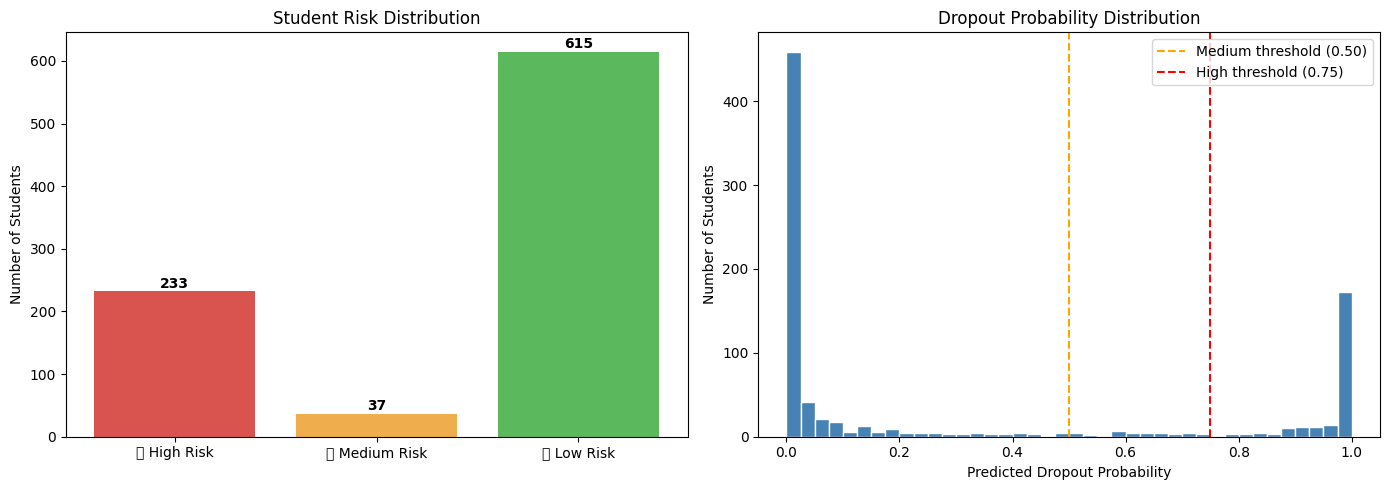

In [37]:
# Full risk distribution breakdown with accuracy per tier
print("=== Risk Level Distribution & Accuracy ===\n")

for level in ['🔴 High Risk', '🟡 Medium Risk', '🟢 Low Risk']:
    subset = risk_df[risk_df['Risk_Level'] == level]
    total = len(subset)
    correct_dropouts = len(subset[(subset['Risk_Level'] == '🔴 High Risk') & 
                                   (subset['Actual'] == 'Dropout')]) if '🔴' in level else None
    actual_dropouts  = (subset['Actual'] == 'Dropout').sum()
    actual_not       = (subset['Actual'] == 'Not Dropout').sum()
    
    print(f"{level}  →  {total} students")
    print(f"   Actual Dropouts    : {actual_dropouts} ({actual_dropouts/total*100:.1f}%)")
    print(f"   Actual Not Dropout : {actual_not} ({actual_not/total*100:.1f}%)")
    print()

# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Risk level counts
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
risk_counts = risk_df['Risk_Level'].value_counts().reindex(
    ['🔴 High Risk', '🟡 Medium Risk', '🟢 Low Risk'])
axes[0].bar(risk_counts.index, risk_counts.values, color=colors)
axes[0].set_title('Student Risk Distribution')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Probability distribution
axes[1].hist(y_proba_binary, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0.50, color='orange', linestyle='--', label='Medium threshold (0.50)')
axes[1].axvline(0.75, color='red',    linestyle='--', label='High threshold (0.75)')
axes[1].set_title('Dropout Probability Distribution')
axes[1].set_xlabel('Predicted Dropout Probability')
axes[1].set_ylabel('Number of Students')
axes[1].legend()

plt.tight_layout()
plt.show()

#  Precision Check Per Risk Tier

In [38]:
# How reliable is each risk tier?
print("=== How Trustworthy is Each Tier? ===\n")

for level, threshold_low, threshold_high in [
    ('🔴 High Risk',    0.75, 1.01),
    ('🟡 Medium Risk',  0.50, 0.75),
    ('🟢 Low Risk',     0.00, 0.50)
]:
    mask = (y_proba_binary >= threshold_low) & (y_proba_binary < threshold_high)
    subset_true = y_test_b[mask]
    subset_pred = (y_proba_binary[mask] >= 0.5).astype(int)
    
    total = mask.sum()
    if total == 0:
        continue
        
    actual_drop_rate = subset_true.mean() * 100
    print(f"{level} ({total} students)")
    print(f"   → {actual_drop_rate:.1f}% are actual dropouts")
    print(f"   → {100 - actual_drop_rate:.1f}% are safe")
    print()

=== How Trustworthy is Each Tier? ===

🔴 High Risk (233 students)
   → 90.1% are actual dropouts
   → 9.9% are safe

🟡 Medium Risk (37 students)
   → 48.6% are actual dropouts
   → 51.4% are safe

🟢 Low Risk (615 students)
   → 9.1% are actual dropouts
   → 90.9% are safe



# Export Full Risk Report

In [39]:
# Build complete report for all test students
full_report = pd.DataFrame({
    'Dropout_Probability_%': (y_proba_binary * 100).round(1),
    'Risk_Level':            [risk_label(p) for p in y_proba_binary],
    'Predicted':             ['Dropout' if p >= 0.5 else 'Not Dropout' 
                              for p in y_proba_binary],
    'Actual':                ['Dropout' if v == 1 else 'Not Dropout' 
                              for v in y_test_b],
    'Correct':               ['✅' if p == a else '❌' 
                              for p, a in zip(
                                  (y_proba_binary >= 0.5).astype(int), 
                                  y_test_b)]
})

# Sort by highest risk first
full_report = full_report.sort_values('Dropout_Probability_%', ascending=False)

print("=== Top 15 Highest Risk Students ===")
print(full_report.head(15).to_string())

# Save to CSV
full_report.to_csv('student_risk_report.csv', index=True)
print("\n✅ Full report saved to student_risk_report.csv")

=== Top 15 Highest Risk Students ===
     Dropout_Probability_%   Risk_Level Predicted       Actual Correct
370                  100.0  🔴 High Risk   Dropout      Dropout       ✅
398                  100.0  🔴 High Risk   Dropout      Dropout       ✅
341                  100.0  🔴 High Risk   Dropout      Dropout       ✅
435                  100.0  🔴 High Risk   Dropout      Dropout       ✅
368                  100.0  🔴 High Risk   Dropout      Dropout       ✅
360                  100.0  🔴 High Risk   Dropout      Dropout       ✅
37                   100.0  🔴 High Risk   Dropout      Dropout       ✅
822                  100.0  🔴 High Risk   Dropout      Dropout       ✅
52                   100.0  🔴 High Risk   Dropout      Dropout       ✅
51                   100.0  🔴 High Risk   Dropout      Dropout       ✅
428                  100.0  🔴 High Risk   Dropout  Not Dropout       ❌
809                  100.0  🔴 High Risk   Dropout      Dropout       ✅
281                  100.0  🔴 High Risk 

# Custom Test Cases

In [40]:
import pandas as pd
import numpy as np

# ============================================================
# HELPER: Build a student profile (fill in what you know,
#         rest defaults to "average/safe" values)
# ============================================================

def make_student(
    # --- Academic 1st sem ---
    cu1_credited=0, cu1_enrolled=6, cu1_evaluations=6,
    cu1_approved=6, cu1_grade=13.0, cu1_without_eval=0,
    # --- Academic 2nd sem ---
    cu2_credited=0, cu2_enrolled=6, cu2_evaluations=6,
    cu2_approved=6, cu2_grade=13.0, cu2_without_eval=0,
    # --- Financial ---
    tuition_up_to_date=1, debtor=0, scholarship=0,
    # --- Personal ---
    age=20, gender=1, marital_status=1, displaced=0,
    intl=0, special_needs=0,
    # --- Academic background ---
    admission_grade=130.0, prev_qual=1, prev_qual_grade=130.0,
    # --- Application ---
    app_mode=1, app_order=1, course=9254,
    daytime_attend=1,
    # --- Family ---
    nationality=1,
    mother_qual=1, father_qual=1,
    mother_occ=5,  father_occ=5,
    # --- Economic context ---
    unemployment=10.8, inflation=1.4, gdp=1.74
):
    return {
        'Marital Status': marital_status,
        'Application mode': app_mode,
        'Application order': app_order,
        'Course': course,
        'Daytime/evening attendance': daytime_attend,
        'Previous qualification': prev_qual,
        'Previous qualification (grade)': prev_qual_grade,
        'Nacionality': nationality,
        "Mother's qualification": mother_qual,
        "Father's qualification": father_qual,
        "Mother's occupation": mother_occ,
        "Father's occupation": father_occ,
        'Admission grade': admission_grade,
        'Displaced': displaced,
        'Educational special needs': special_needs,
        'Debtor': debtor,
        'Tuition fees up to date': tuition_up_to_date,
        'Gender': gender,
        'Scholarship holder': scholarship,
        'Age at enrollment': age,
        'International': intl,
        'Curricular units 1st sem (credited)': cu1_credited,
        'Curricular units 1st sem (enrolled)': cu1_enrolled,
        'Curricular units 1st sem (evaluations)': cu1_evaluations,
        'Curricular units 1st sem (approved)': cu1_approved,
        'Curricular units 1st sem (grade)': cu1_grade,
        'Curricular units 1st sem (without evaluations)': cu1_without_eval,
        'Curricular units 2nd sem (credited)': cu2_credited,
        'Curricular units 2nd sem (enrolled)': cu2_enrolled,
        'Curricular units 2nd sem (evaluations)': cu2_evaluations,
        'Curricular units 2nd sem (approved)': cu2_approved,
        'Curricular units 2nd sem (grade)': cu2_grade,
        'Curricular units 2nd sem (without evaluations)': cu2_without_eval,
        'Unemployment rate': unemployment,
        'Inflation rate': inflation,
        'GDP': gdp
    }


# ============================================================
# FEATURE ENGINEERING — must match exactly what you did in
# Step 5 & 16 during training
# ============================================================

def add_features(df):
    df = df.copy()
    df['pass_rate_1st_sem'] = (
        df['Curricular units 1st sem (approved)'] /
        (df['Curricular units 1st sem (enrolled)'] + 1e-5)
    )
    df['pass_rate_2nd_sem'] = (
        df['Curricular units 2nd sem (approved)'] /
        (df['Curricular units 2nd sem (enrolled)'] + 1e-5)
    )
    df['financial_risk'] = (
        (df['Tuition fees up to date'] == 0).astype(int) + df['Debtor']
    )
    df['grade_improvement'] = (
        df['Curricular units 2nd sem (grade)'] -
        df['Curricular units 1st sem (grade)']
    )
    df['total_approved'] = (
        df['Curricular units 1st sem (approved)'] +
        df['Curricular units 2nd sem (approved)']
    )
    df['eval_rate_1st_sem'] = (
        df['Curricular units 1st sem (evaluations)'] /
        (df['Curricular units 1st sem (enrolled)'] + 1e-5)
    )
    df['eval_rate_2nd_sem'] = (
        df['Curricular units 2nd sem (evaluations)'] /
        (df['Curricular units 2nd sem (enrolled)'] + 1e-5)
    )
    df['sem_consistency'] = abs(
        df['pass_rate_1st_sem'] - df['pass_rate_2nd_sem']
    )
    df['total_evaluations'] = (
        df['Curricular units 1st sem (evaluations)'] +
        df['Curricular units 2nd sem (evaluations)']
    )
    df['grade_trend'] = (
        df['Curricular units 2nd sem (grade)'] /
        (df['Curricular units 1st sem (grade)'] + 1e-5)
    )
    df['economic_pressure'] = (
        df['Unemployment rate'] * df['Debtor']
    )
    return df


# ============================================================
# PREDICTOR FUNCTION
# ============================================================

def predict_student(student_dict, label="Student"):
    df = pd.DataFrame([student_dict])
    df = add_features(df)

    # Align columns to training data
    df = df.reindex(columns=X_eng.columns, fill_value=0)

    scaled = scaler_b.transform(df)
    prob   = xgb_binary.predict_proba(scaled)[0][1]
    pred   = xgb_binary.predict(scaled)[0]

    risk = ('🔴 HIGH RISK'   if prob >= 0.75 else
            '🟡 MEDIUM RISK' if prob >= 0.50 else
            '🟢 LOW RISK')

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  Dropout Probability : {prob*100:.1f}%")
    print(f"  Risk Level          : {risk}")
    print(f"  Prediction          : {'⚠️  DROPOUT' if pred==1 else '✅ NOT DROPOUT'}")
    print(f"{'='*50}")
    return prob, pred


# ============================================================
# TEST CASES — 5 realistic student profiles
# ============================================================

# 1️⃣ Classic dropout: fails everything, owes tuition
s1 = make_student(
    cu1_approved=1,  cu1_grade=8.0,  cu1_enrolled=6,
    cu2_approved=0,  cu2_grade=0.0,  cu2_enrolled=6,
    tuition_up_to_date=0, debtor=1,
    age=25, admission_grade=100.0
)

# 2️⃣ Strong student: passes all, pays tuition, scholarship
s2 = make_student(
    cu1_approved=6,  cu1_grade=15.0, cu1_enrolled=6,
    cu2_approved=6,  cu2_grade=16.0, cu2_enrolled=6,
    tuition_up_to_date=1, debtor=0, scholarship=1,
    age=19, admission_grade=160.0
)

# 3️⃣ Borderline: decent grades but has debt, older student
s3 = make_student(
    cu1_approved=4,  cu1_grade=11.0, cu1_enrolled=6,
    cu2_approved=3,  cu2_grade=10.0, cu2_enrolled=6,
    tuition_up_to_date=1, debtor=1,
    age=30, admission_grade=115.0
)

# 4️⃣ Struggling: failed 2nd sem badly, not paying
s4 = make_student(
    cu1_approved=5,  cu1_grade=13.0, cu1_enrolled=6,
    cu2_approved=1,  cu2_grade=7.0,  cu2_enrolled=6,
    tuition_up_to_date=0, debtor=0,
    age=22, admission_grade=120.0
)

# 5️⃣ Average student: passes most, tuition ok
s5 = make_student(
    cu1_approved=5,  cu1_grade=12.0, cu1_enrolled=6,
    cu2_approved=5,  cu2_grade=12.5, cu2_enrolled=6,
    tuition_up_to_date=1, debtor=0,
    age=21, admission_grade=130.0
)

# Run all predictions
predict_student(s1, "Student 1 — Classic Dropout Profile")
predict_student(s2, "Student 2 — Strong Student Profile")
predict_student(s3, "Student 3 — Borderline / At Risk")
predict_student(s4, "Student 4 — Declining Performance")
predict_student(s5, "Student 5 — Average Student")


  Student 1 — Classic Dropout Profile
  Dropout Probability : 100.0%
  Risk Level          : 🔴 HIGH RISK
  Prediction          : ⚠️  DROPOUT

  Student 2 — Strong Student Profile
  Dropout Probability : 0.0%
  Risk Level          : 🟢 LOW RISK
  Prediction          : ✅ NOT DROPOUT

  Student 3 — Borderline / At Risk
  Dropout Probability : 97.1%
  Risk Level          : 🔴 HIGH RISK
  Prediction          : ⚠️  DROPOUT

  Student 4 — Declining Performance
  Dropout Probability : 100.0%
  Risk Level          : 🔴 HIGH RISK
  Prediction          : ⚠️  DROPOUT

  Student 5 — Average Student
  Dropout Probability : 3.0%
  Risk Level          : 🟢 LOW RISK
  Prediction          : ✅ NOT DROPOUT


(np.float32(0.030069044), np.int64(0))